In [ ]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scipy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import scipy

## Main data operation, smooth, find peaks and return period of sine wave

In [2]:
def get_period(data: pd.DataFrame):
    data['smooth_angle'] = scipy.signal.savgol_filter(data['angle'], window_length=50, polyorder=2)
    peaks_indices, _ = scipy.signal.find_peaks(data["smooth_angle"], prominence=0.5)
    peak_times = data["time"].iloc[peaks_indices]
    return peak_times, 1 / (len(peak_times) / (data["time"].max()))

## Time filtering

In [3]:
def reset_time(data: pd.DataFrame):
    data["time"] = data["time"] - data["time"].min()
    return data
    
def filter_time(data: pd.DataFrame, min_time: float, max_time: float):
    return data[(data["time"] >= min_time) & (data["time"] < max_time)]

# Load data into variables

In [4]:
def load_data(path: str):
    return pd.read_csv(path)

positions_1 = load_data("../data/output-1-positions.csv")
angles_1 = load_data("../data/output-1-angles.csv")

positions_2 = load_data("../data/output-3-positions.csv")
angles_2 = load_data("../data/output-3-angles.csv")

## Filter data

In [5]:
angles_1 = reset_time(angles_1)
angles_2 = reset_time(angles_2)

# magic numbers are time ranges, chosen by zooming in on interactive graph
angles_1 = reset_time(filter_time(angles_1, 0.7, 34.62))
angles_2 = reset_time(filter_time(angles_2, 9.5, 34.7))

## Function to generate & draw graph, labeled with peaks

In [8]:
def generate_graph(data: pd.DataFrame, line_color=None):
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    ax1.set_ylabel(r"$\theta$")
    ax1.set_xlabel(r"$T_0 + t$")

    peak_times, period = get_period(data)
    
    ax1.plot(
        data["time"],
        data["angle"],
        "o-",
        label="T = %.3f" % (period),
        color=line_color
    )
    
    ax1.vlines(
        x=peak_times,
        ymin=data["angle"].min(),
        ymax=data["angle"].max(),
        color='red',
        linestyle='--',
        alpha=0.7,
        label="%s Peaks." % (len(peak_times))
    )
    ax1.legend(loc="upper left")

    return fig1, ax1


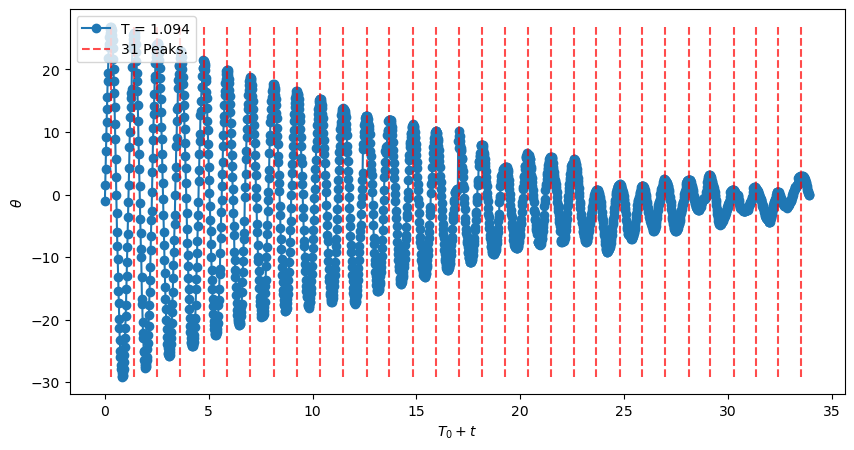

In [9]:
fig1, ax1 = generate_graph(angles_1)
fig1.savefig("./images/angles_1_peaks.png", bbox_inches='tight')
plt.show()

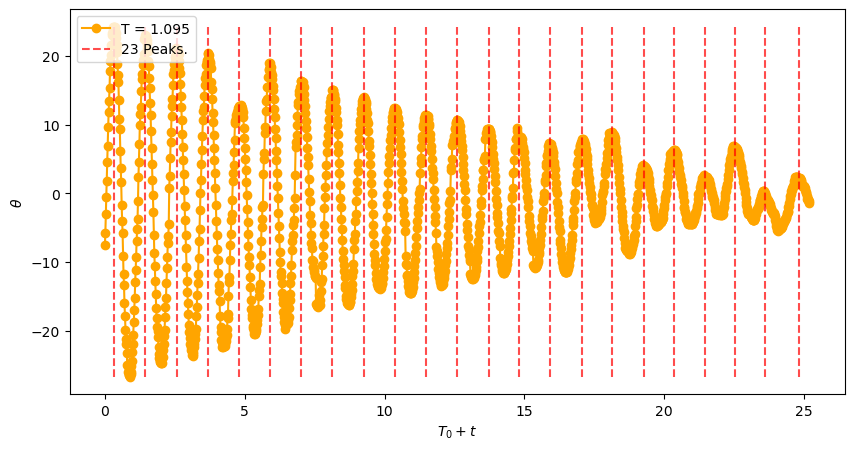

In [10]:
fig1, ax1 = generate_graph(angles_2, "orange")
fig1.savefig("./images/angles_2_peaks.png", bbox_inches='tight')
plt.show()